In [1]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### Load data

In [4]:
ws_dict = fn.load_reanalysis_wind_speed(FILEPATH)

In [5]:
# Check size
nbytes = []
for k, v in ws_dict.items():
    nbytes.append(v.nbytes)
sum(nbytes) / 1024 ** 3

0.00450664758682251

### Notable droughts
- 2010: https://wattclarity.com/articles/2022/06/seasons-of-low-wind-and-solar-output-will-influence-the-shape-of-the-nem/
- 2017 and 2024: https://wattclarity.com.au/articles/2024/07/09july-q2-wind-yield/

In [5]:
def sel_and_reindex(da, time):
    """
    Return selected array without timestamps

    da: array
    time: time selector for xarray array e.g. slice, string
    """
    da = da.sel(time=time)
    da["time"] = range(len(da["time"]))
    return da

In [6]:
def plot_ts_year_comparison(ax, da, time, roll, q, color="tab:blue", label="", title="", fill_between=True):
    """
    Time series plot of data

    ax: axes to plot on
    da: array
    time: time selector for xarray array e.g. slice, string
    roll: int, number of time steps in rolling average
    q: quantile, drought definition
    color: str, color of line
    label: str, line label
    title: str, plot title
    """
    # rolling mean
    da_roll = da.rolling(time=roll).mean()

    # drought threshold
    da_q = da_roll.quantile(q, "time")
    
    # Select dates to plot
    da_plot = sel_and_reindex(da_roll, time)

    # plot
    da_plot.plot(ax=ax, color=color, label=label, zorder=0)
    if fill_between:
        ax.fill_between(
            da_plot.time, y1=da_plot, y2=da_q, where=(da_plot < da_q), interpolate=True, color=color, alpha=0.5, zorder=1
        )
    ax.axhline(da_q, color=color)
    ax.set_title(title, fontsize=10)

In [7]:
years = ["2010", "2017", "2024"]

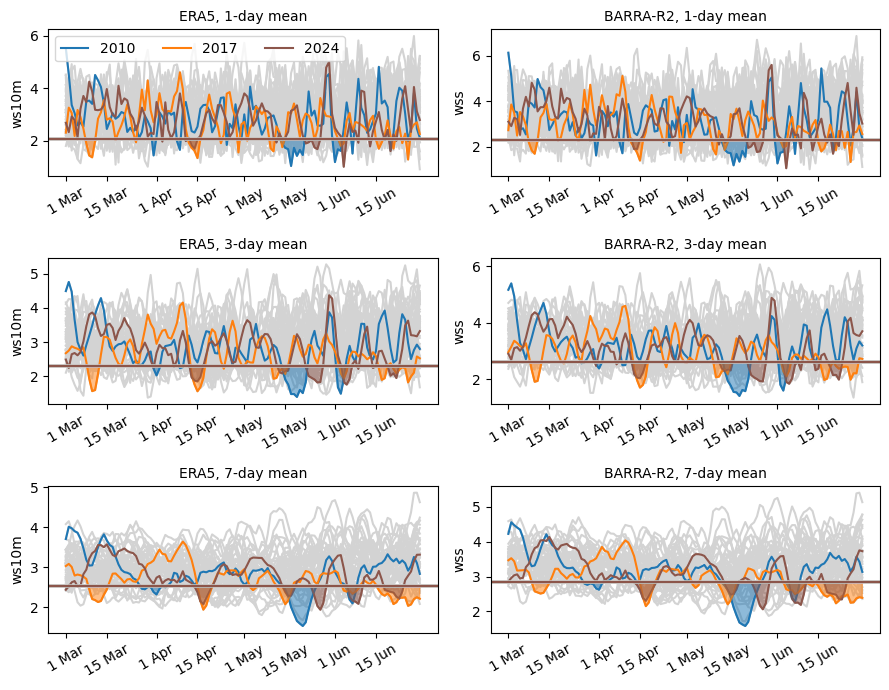

In [45]:
fig, ax = plt.subplots(3, 2, figsize=(9, 7))

datasets = {"ERA5": "ws10m", "BARRA-R2": "wss"}
rolls = [1, 3, 7]
all_years = [str(i) for i in range(1979, 2025)]

for i, roll in enumerate(rolls):

    for j, year in enumerate(all_years):
        time = slice("03-"+year, "06-"+year)
        d = pd.date_range("03-"+year, "30-06-"+year)

        for k, (dataset, var_name) in enumerate(datasets.items()):
            data = ws_dict[dataset+"_NEM_NEM_wind_2025_weighted"]#[var_name]
            
            plot_ts_year_comparison(
                ax[i,k],
                data,# ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
                time,
                roll,
                0.1,
                color="lightgray",
                fill_between=False
            )
    
    for j, (year, color) in enumerate(zip(
        years, ["tab:blue", "tab:orange", "tab:brown"]#, "tab:green", "tab:pink"]
        # years, ["tab:blue", "tab:orange", "tab:brown", "tab:green", "tab:pink"]
    )):
        time = slice("03-"+year, "06-"+year)

        for k, (dataset, var_name) in enumerate(datasets.items()):
            data = ws_dict[dataset+"_NEM_NEM_wind_2025_weighted"]#[var_name]
            
            plot_ts_year_comparison(
                ax[i,k],
                data,# ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["ws10m"],
                time,
                roll,
                0.1,
                color=color,
                label=year,
                title=dataset+", "+str(roll)+"-day mean"
            )

ax[0,0].legend(ncols=3)
for a in ax.flatten():
    a.set_xlabel("")
    a.set_xticks(np.where((d.day == 1) | (d.day == 15))[0])
    a.set_xticklabels([
        "1 Mar", "15 Mar","1 Apr", "15 Apr", "1 May", "15 May", "1 Jun", "15 Jun"
    ], rotation=30)
plt.tight_layout()

### Drought definition

10th percentile, based on AEMO report for wind lulls (pg 31, Fig 41): https://www.aemo.com.au/-/media/files/major-publications/qed/2025/qed-q3-2025.pdf?rev=7436be91333e4603bc59158b0bf095a1&sc_lang=en&hash=A49B4BC337B25B842566B8F5EE4C8331 

In [8]:
def cumsum_reset_on_mask(data, mask, dim="time"):
    """
    Cumulative sum, resetting to zero wherever 'mask' == 0.
    
    data : xr.DataArray, Array to accumulate.
    mask : xr.DataArray, Binary array of the same shape, where 0 means "reset".
    dim : str, Dimension along which to accumulate (default: "time").
    """
    a = data.values
    reset = (mask.values == 0)

    out = np.zeros_like(a, dtype=float)

    axis = data.get_axis_num(dim)
    a = np.moveaxis(a, axis, 0)
    reset = np.moveaxis(reset, axis, 0)
    out = np.moveaxis(out, axis, 0)

    acc = np.zeros_like(a[0], dtype=float)
    for i in range(a.shape[0]):
        acc = np.where(reset[i], 0, acc + a[i])
        out[i] = acc

    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=data.coords, dims=data.dims, attrs=data.attrs)

In [9]:
DROUGHT_Q = 0.1

In [10]:
for k,v in ws_dict.items():
    ws_dict[k] = v.to_dataset(name=v.name)
    ds = ws_dict[k]

    # Compute drought days and cumulative lengths
    drought_days = xr.where(v < v.quantile(DROUGHT_Q, "time"), 1, 0)
    drought_sum = cumsum_reset_on_mask(drought_days, drought_days).astype("int")

    # Accumulate wind speed anomalies over drought days
    ws_clim = v.mean("time")
    ws_anoms = v - ws_clim
    ws_severity = cumsum_reset_on_mask(ws_anoms, drought_days)

    ws_dict[k]["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    ws_dict[k]["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

In [12]:
import xclim

In [145]:
t = ws_dict["ERA5_NEM_NEM_wind_2030_unweighted"]["ws10m"].quantile(DROUGHT_Q, "time").values

In [146]:
drought_days = xr.where(
    ws_dict["ERA5_NEM_NEM_wind_2030_unweighted"]["ws10m"] < t,
    True, False
).assign_attrs(
        units="m/s"
    )

In [147]:
ws_dict["ERA5_NEM_NEM_wind_2030_unweighted"]["ws10m"]

<xarray.DataArray 'ws10m' (time: 16802)> Size: 134kB
array([4.17255 , 4.59833 , 4.446753, ..., 1.773398, 2.329605, 2.551892])
Coordinates:
  * time      (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2024-12-31
    quantile  float64 8B 0.1

In [148]:
x = xclim.indices.run_length.find_events(
    drought_days,
    window=1,
    data=ws_dict["ERA5_NEM_NEM_wind_2030_unweighted"]["ws10m"].assign_attrs(
        units="m/s"
    )
)

(array([661., 234.,  97.,  42.,   0.,  10.,   3.,   0.,   2.,   1.]),
 array([1. , 1.8, 2.6, 3.4, 4.2, 5. , 5.8, 6.6, 7.4, 8.2, 9. ]),
 <BarContainer object of 10 artists>)

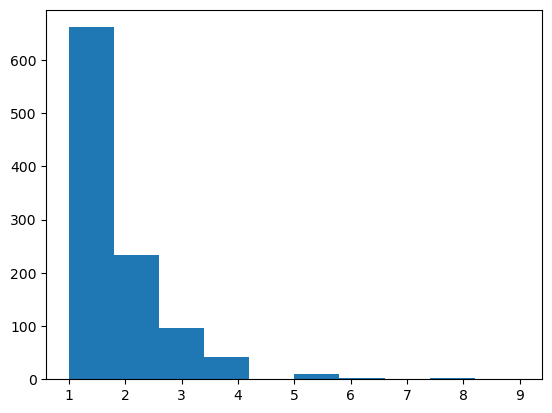

In [149]:
plt.hist(x["event_length"].dropna("event"))

(array([  5.,   3.,   9.,  26.,  60., 104., 153., 210., 234., 246.]),
 array([1.31504883, 1.4081321 , 1.50121537, 1.59429863, 1.6873819 ,
        1.78046517, 1.87354843, 1.9666317 , 2.05971497, 2.15279824,
        2.2458815 ]),
 <BarContainer object of 10 artists>)

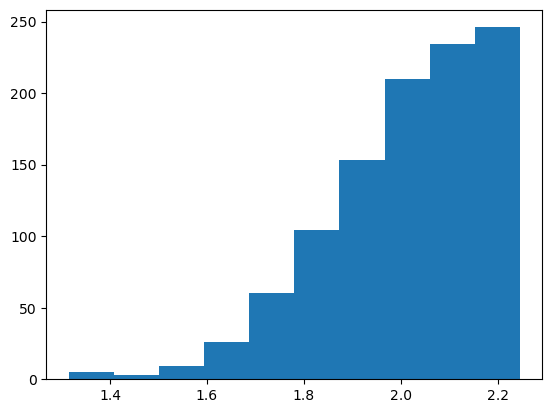

In [150]:
plt.hist(
    (x["event_sum"] / x["event_length"]).dropna("event")
)

(array([171.,  81.,  85.,  78.,  87.,  73.,  83.,  87., 104., 201.]),
 array([ 1. ,  2.1,  3.2,  4.3,  5.4,  6.5,  7.6,  8.7,  9.8, 10.9, 12. ]),
 <BarContainer object of 10 artists>)

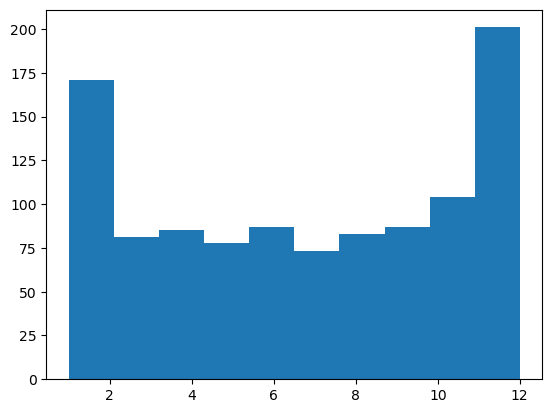

In [151]:
plt.hist(pd.to_datetime(x["event_start"].dropna("event")).month)

In [152]:
y = x.assign_coords(time=("event", x["event_start"].data)).drop_vars("event_start")

In [153]:
y = y.swap_dims({"event": "time"}).dropna("time")

In [154]:
y["event_length"]

<xarray.DataArray 'event_length' (time: 1050)> Size: 8kB
array([1., 3., 1., ..., 3., 1., 1.])
Coordinates:
  * time      (time) datetime64[ns] 8kB 1979-01-15 1979-03-06 ... 2024-12-29
    event     (time) int64 8kB 1 2 3 4 5 6 7 ... 1045 1046 1047 1048 1049 1050
    quantile  float64 8B 0.1
Attributes:
    units:    1

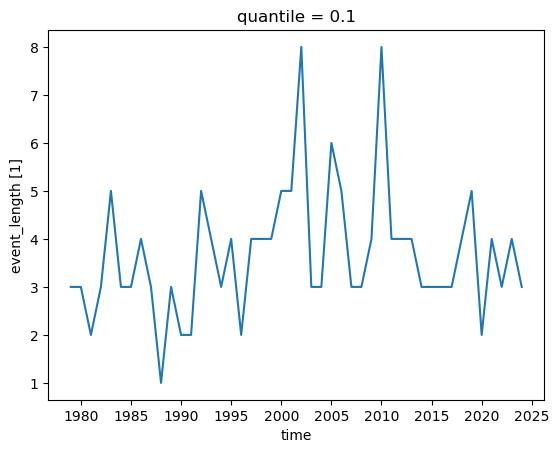

In [157]:
y["event_length"].isel(
    time=y.time.dt.month.isin([4, 5, 6, 7, 8, 9, 10])
).resample(time="1YS").max().plot()

In [138]:
x

<xarray.DataArray 'ws10m' (time: 46)> Size: 368B
array([3., 4., 9., 3., 5., 3., 3., 4., 3., 3., 3., 2., 4., 6., 4., 3., 4.,
       4., 4., 3., 4., 5., 6., 8., 5., 4., 6., 5., 2., 3., 4., 8., 5., 4.,
       4., 4., 3., 7., 5., 3., 3., 2., 4., 3., 4., 3.])
Coordinates:
  * time      (time) datetime64[ns] 368B 1979-01-01 1980-01-01 ... 2024-01-01
    quantile  float64 8B 0.1
Attributes:
    units:    d

In [ ]:
x.resample(event_start

In [137]:
x = xclim.indices.generic.spell_length(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["ws10m"].assign_attrs(
        units="m/s"
    ),
    # ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["ws10m"].assign_attrs(
    #     units="m/s"
    # ).quantile(DROUGHT_Q, dim="time"),
    str(t)+" m/s",
#     window=1,
    freq="YS",
    reducer="max",
    op="<"
)

In [20]:
x

<xarray.DataArray 'ws10m' (time: 46)> Size: 368B
array([3., 4., 9., 3., 5., 3., 3., 4., 3., 3., 3., 2., 4., 6., 4., 3., 4.,
       4., 4., 3., 4., 5., 6., 8., 5., 4., 6., 5., 2., 3., 4., 8., 5., 4.,
       4., 4., 3., 7., 5., 3., 3., 2., 4., 3., 4., 3.])
Coordinates:
  * time      (time) datetime64[ns] 368B 1979-01-01 1980-01-01 ... 2024-01-01
    quantile  float64 8B 0.1
Attributes:
    units:    d

In [44]:
w = ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"].resample(time="1YS").max()

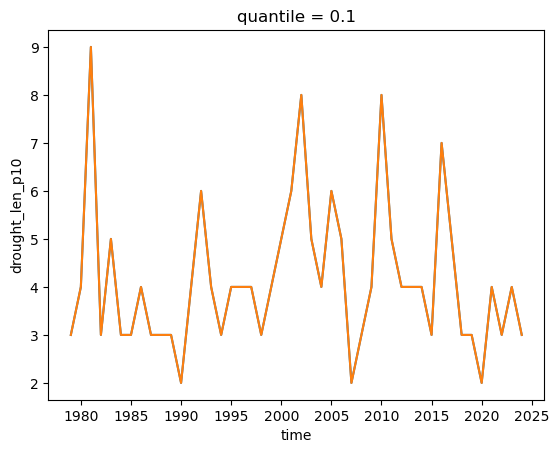

In [46]:
x.plot()
w.plot()

In [36]:
ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"].groupby("time.year").max()

<xarray.DataArray 'drought_len_p10' (year: 46)> Size: 368B
array([3, 4, 9, 3, 5, 3, 3, 4, 3, 3, 3, 2, 4, 6, 4, 3, 4, 4, 4, 3, 4, 5,
       6, 8, 5, 4, 6, 5, 2, 3, 4, 8, 5, 4, 4, 4, 3, 7, 5, 3, 3, 2, 4, 3,
       4, 3])
Coordinates:
  * year      (year) int64 368B 1979 1980 1981 1982 1983 ... 2021 2022 2023 2024
    quantile  float64 8B 0.1

### Drought metrics

Number of drought days per year

In [10]:
def n_drought_days(da):
    """
    Return number of drought days per year
    """
    # return da.resample(time="1YS").sum()
    return xr.where(da > 0, 1, 0).resample(time="1YS").sum()

In [144]:
def n_droughts(da, min_len=1):
    """
    Return number of droughts of a minimum length per year
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(da >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return xr.where(diff == -1, 1, 0).resample(time="1YS").sum()

In [192]:
def mean_drought(da):
    """
    Return mean drought length each year
    """
    return da.where(da > 0).groupby("time.year").mean()

In [134]:
def longest_drought(da):
    """
    Return longest drought each year
    """
    return da.groupby("time.year").max()

In [135]:
def _get_plot_stats(fn, data_dict, data_name_dict, var_name):
    """
    Getg plotting data for data_dict.

    fn: function to pass data through
    data_dict: dictionary, containing arrays to process
    data_name_dict, dictionary, keys are keys of data_dict and values are corresponding 'clean' names for plotting
    var_name, str, key of data_dict[key]
    """
    old_names, new_names = list(data_name_dict.keys()), list(data_name_dict.values())
    
    new_arrays = [
        fn(
            data_dict[old_names[i]][var_name]
        ).expand_dims(
            {"da_number": [i]}
        ).assign_coords(
            da_name=("da_number", [new_names[i]])
        )
        for i in range(len(old_names))
    ]
    
    new_array = xr.concat(new_arrays, dim="da_number")
    
    return new_array

In [104]:
def plot_heat_ts(da, name, title, xlabel="Year", ylabel="", vmin=None, vmax=None):
    """
    Plot heatmap time series

    da: array to plot with da_number dimension and da_name coordinate
    name: str, variable name for colorbar label
    title: str, plot title
    xlabel, ylabel: str, x= and y-axis labels
    vmin, vmax: int or float, minimum values for colorbar, default is None
    """
    fig, ax = plt.subplots(1, 1, figsize=(7,1))

    da.rename(name).plot(ax=ax, vmin=vmin, vmax=vmax)
    
    ax.set_xlabel(ylabel)
    
    ax.set_yticks(range(len(da.da_number)))
    ax.set_yticklabels(da.da_name.values)
    ax.set_ylabel("")
    ax.invert_yaxis()
    
    ax.set_title(title, fontsize=10)

In [106]:
var_name = "drought_len_p10"

In [145]:
n_days_era = _get_plot_stats(
    n_drought_days,
    ws_dict,
    {
        "ERA5_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "ERA5_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "ERA5_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "ERA5_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "ERA5_SWIS": "SWIS",
        "ERA5_NWIS": "NWIS"
    },
    var_name
)

In [150]:
n_droughts_era = _get_plot_stats(
    n_droughts,
    ws_dict,
    {
        "ERA5_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "ERA5_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "ERA5_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "ERA5_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "ERA5_SWIS": "SWIS",
        "ERA5_NWIS": "NWIS"
    },
    var_name
)

In [193]:
mean_len_droughts_era = _get_plot_stats(
    mean_drought,
    ws_dict,
    {
        "ERA5_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "ERA5_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "ERA5_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "ERA5_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "ERA5_SWIS": "SWIS",
        "ERA5_NWIS": "NWIS"
    },
    var_name
)

In [136]:
longest_droughts_era = _get_plot_stats(
    longest_drought,
    ws_dict,
    {
        "ERA5_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "ERA5_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "ERA5_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "ERA5_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "ERA5_SWIS": "SWIS",
        "ERA5_NWIS": "NWIS"
    },
    var_name
)

In [146]:
n_days_barra = _get_plot_stats(
    n_drought_days,
    ws_dict,
    {
        "BARRA-R2_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "BARRA-R2_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "BARRA-R2_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "BARRA-R2_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "BARRA-R2_SWIS": "SWIS",
        "BARRA-R2_NWIS": "NWIS"
    },
    var_name
)

In [151]:
n_droughts_barra = _get_plot_stats(
    n_droughts,
    ws_dict,
    {
        "BARRA-R2_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "BARRA-R2_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "BARRA-R2_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "BARRA-R2_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "BARRA-R2_SWIS": "SWIS",
        "BARRA-R2_NWIS": "NWIS"
    },
    var_name
)

In [194]:
mean_len_droughts_barra = _get_plot_stats(
    mean_drought,
    ws_dict,
    {
        "BARRA-R2_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "BARRA-R2_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "BARRA-R2_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "BARRA-R2_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "BARRA-R2_SWIS": "SWIS",
        "BARRA-R2_NWIS": "NWIS"
    },
    var_name
)

In [137]:
longest_droughts_barra = _get_plot_stats(
    longest_drought,
    ws_dict,
    {
        "BARRA-R2_NEM_NEM_wind_2025_weighted": "NEM_2025",
        "BARRA-R2_NEM_NEM_wind_2050_weighted": "NEM_2050",
        "BARRA-R2_NEM_SE_wind_2025_weighted": "NEM_SE_2025",
        "BARRA-R2_NEM_SE_wind_2050_weighted": "NEM_SE_2050",
        "BARRA-R2_SWIS": "SWIS",
        "BARRA-R2_NWIS": "NWIS"
    },
    var_name
)

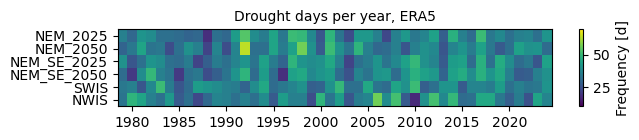

In [147]:
plot_heat_ts(n_days_era, "Frequency [d]", "Drought days per year, ERA5", vmin=10, vmax=70)

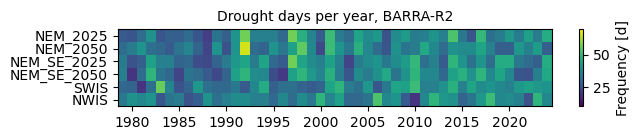

In [148]:
plot_heat_ts(n_days_barra, "Frequency [d]", "Drought days per year, BARRA-R2", vmin=10, vmax=70)

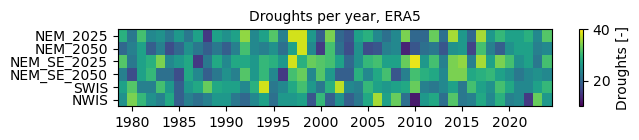

In [158]:
plot_heat_ts(n_droughts_era, "Droughts [-]", "Droughts per year, ERA5", vmin=10, vmax=40)

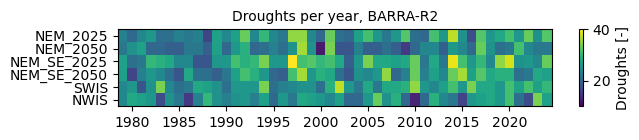

In [159]:
plot_heat_ts(n_droughts_barra, "Droughts [-]", "Droughts per year, BARRA-R2", vmin=10, vmax=40)

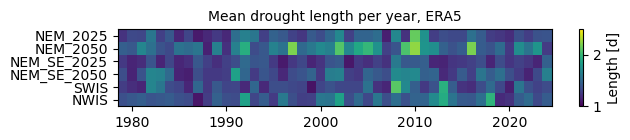

In [203]:
plot_heat_ts(mean_len_droughts_era, "Length [d]", "Mean drought length per year, ERA5", vmin=1, vmax=2.5)

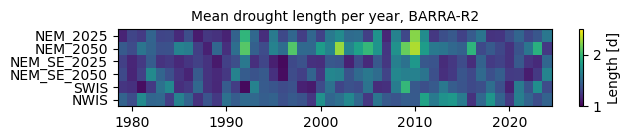

In [204]:
plot_heat_ts(mean_len_droughts_barra, "Length [d]", "Mean drought length per year, BARRA-R2", vmin=1, vmax=2.5)

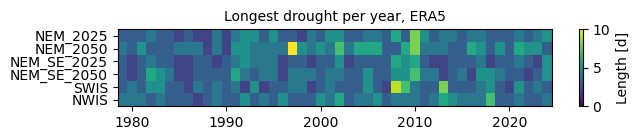

In [140]:
plot_heat_ts(longest_droughts_era, "Length [d]", "Longest drought per year, ERA5", vmin=0, vmax=10)

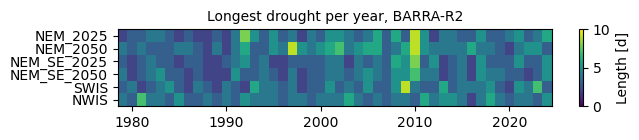

In [141]:
plot_heat_ts(longest_droughts_barra, "Length [d]", "Longest drought per year, BARRA-R2", vmin=0, vmax=10)

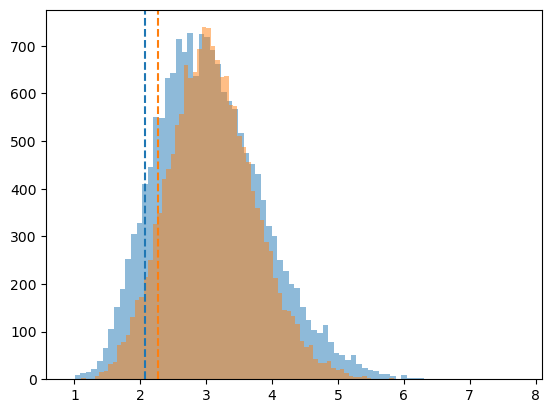

In [182]:
fig, ax = plt.subplots(1, 1)

_ = ax.hist(ws_dict["ERA5_NEM_NEM_wind_2025_weighted"].ws10m, "fd", alpha=0.5)
ax.axvline(ws_dict["ERA5_NEM_NEM_wind_2025_weighted"].ws10m.quantile(0.1, "time"), ls="--")

_ = ax.hist(ws_dict["ERA5_NEM_NEM_wind_2050_weighted"].ws10m, "fd", alpha=0.5)
ax.axvline(ws_dict["ERA5_NEM_NEM_wind_2050_weighted"].ws10m.quantile(0.1, "time"), ls="--", color="tab:orange")

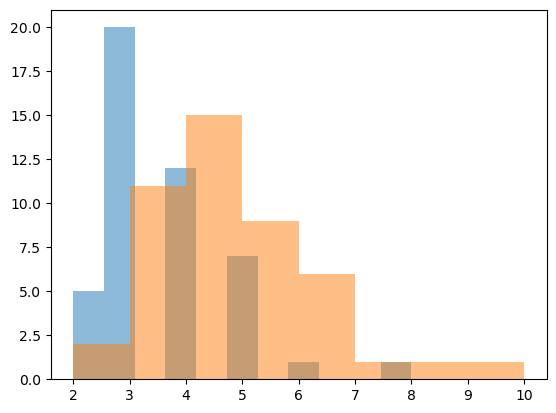

In [177]:
_ = plt.hist(longest_drought(ws_dict["ERA5_NEM_NEM_wind_2025_weighted"].drought_len_p10), "fd", alpha=0.5)
_ = plt.hist(longest_drought(ws_dict["ERA5_NEM_NEM_wind_2050_weighted"].drought_len_p10), "fd", alpha=0.5)

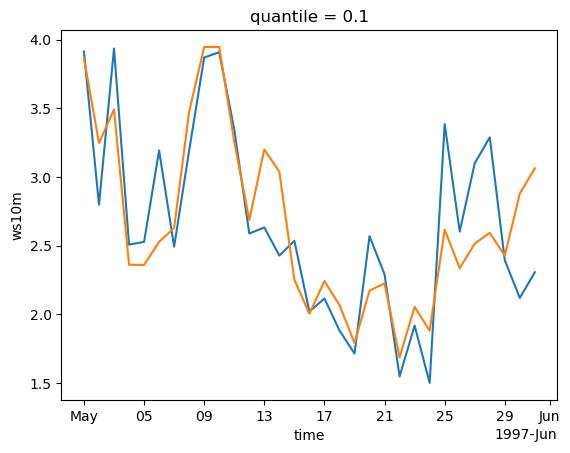

In [172]:
ws_dict["ERA5_NEM_NEM_wind_2025_weighted"].sel(time="1997-05")["ws10m"].plot()
ws_dict["ERA5_NEM_NEM_wind_2050_weighted"].sel(time="1997-05")["ws10m"].plot()

In [173]:
ws_dict["ERA5_NEM_NEM_wind_2025_weighted"].quantile(0.1, "time")

<xarray.Dataset> Size: 32B
Dimensions:               ()
Coordinates:
    quantile              float64 8B 0.1
Data variables:
    ws10m                 float64 8B 2.07
    drought_len_p10       float64 8B 0.0
    drought_severity_p10  float64 8B -0.8927

In [174]:
ws_dict["ERA5_NEM_NEM_wind_2050_weighted"].quantile(0.1, "time")

<xarray.Dataset> Size: 32B
Dimensions:               ()
Coordinates:
    quantile              float64 8B 0.1
Data variables:
    ws10m                 float64 8B 2.269
    drought_len_p10       float64 8B 0.0
    drought_severity_p10  float64 8B -0.7408

Number of drought periods per year

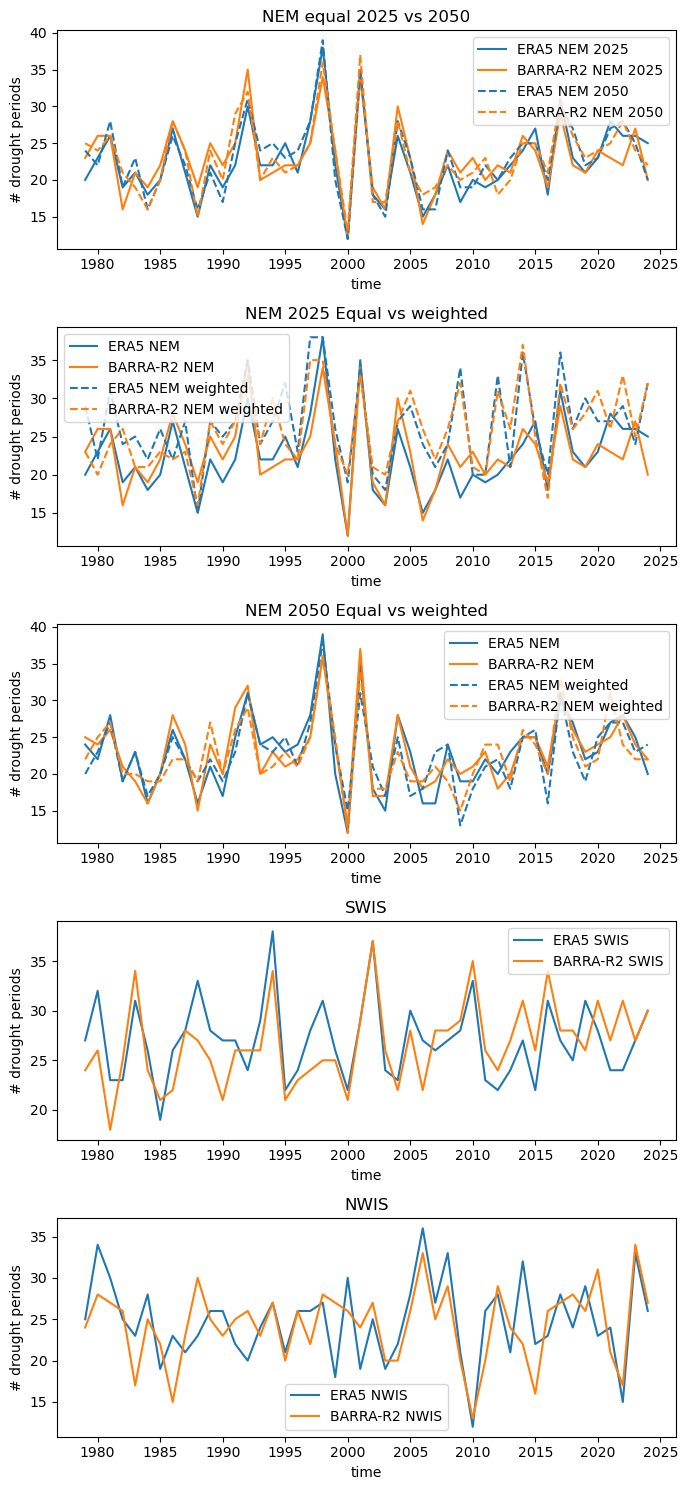

In [36]:
min_len = 1

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

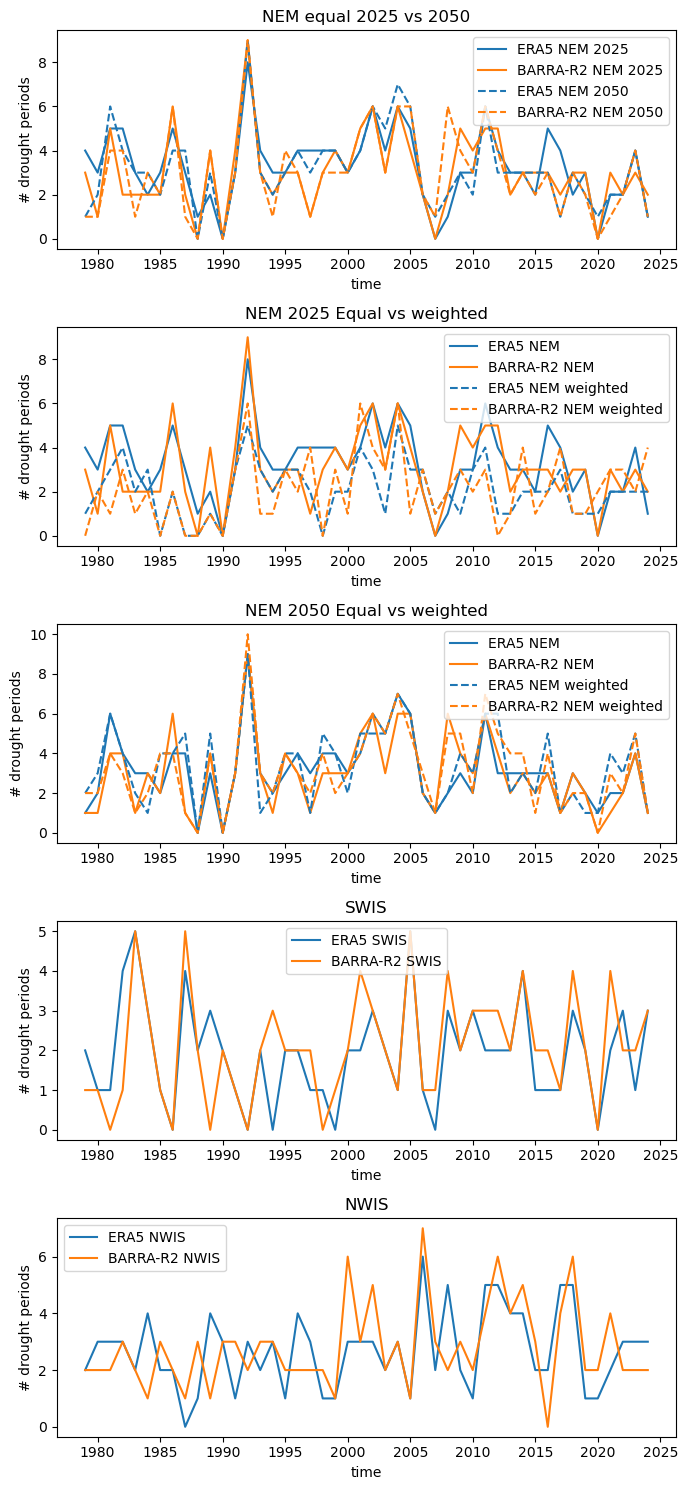

In [37]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

Longest drought per year

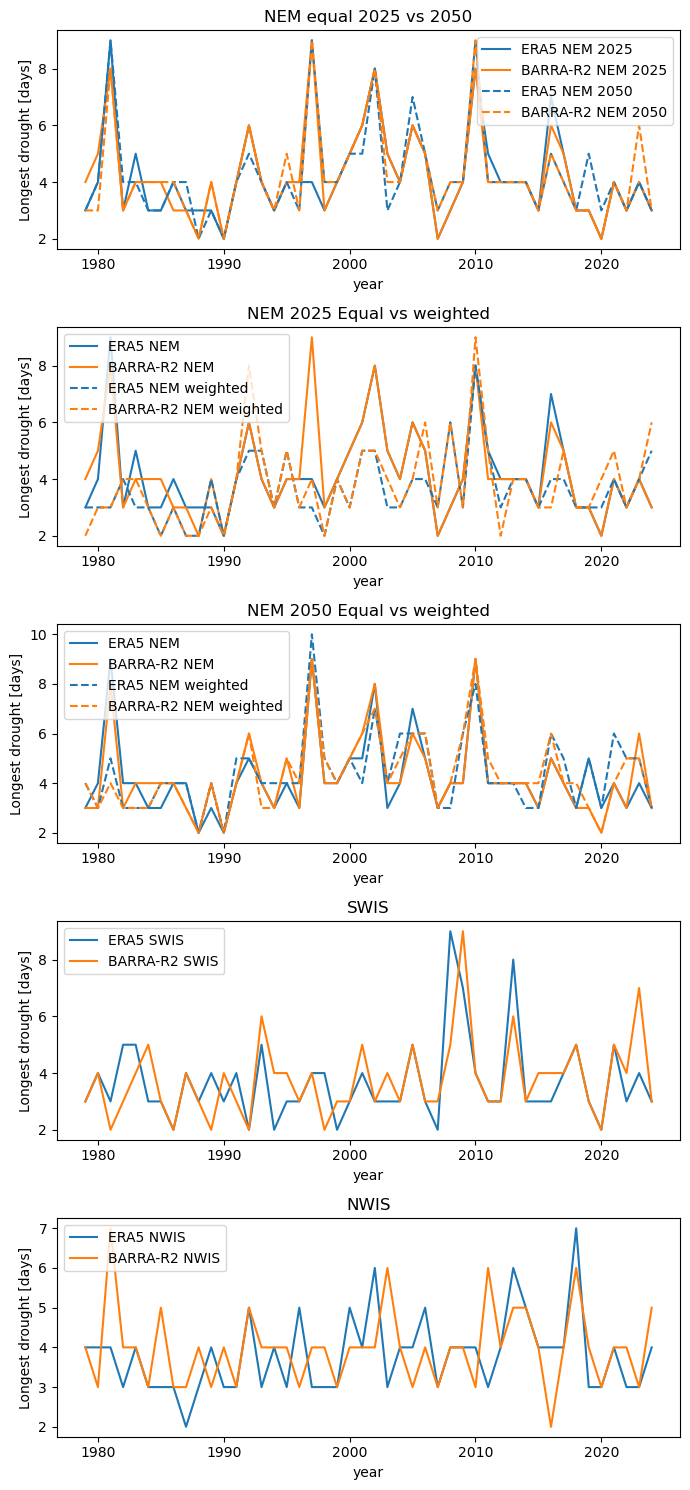

In [34]:
fig, ax = plt.subplots(5, 1, figsize=(7, 15))

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2025")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="ERA5 SWIS")
longest_drought(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

longest_drought(
    ws_dict["ERA5_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="ERA5 NWIS")
longest_drought(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Longest drought [days]")
    
plt.tight_layout()

Accumulated drought intensity

In [13]:
def max_intensity(da, mask, min_len=1):
    """
    Return annual max of drought intensity

    da: array of accumulated wind speed anomalies on drought days
    mask: array of drought periods
    min_len: int, minimum number of consecutive drought days per drought period
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(mask >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return da.where(diff == -1).resample(time="1YS").min()

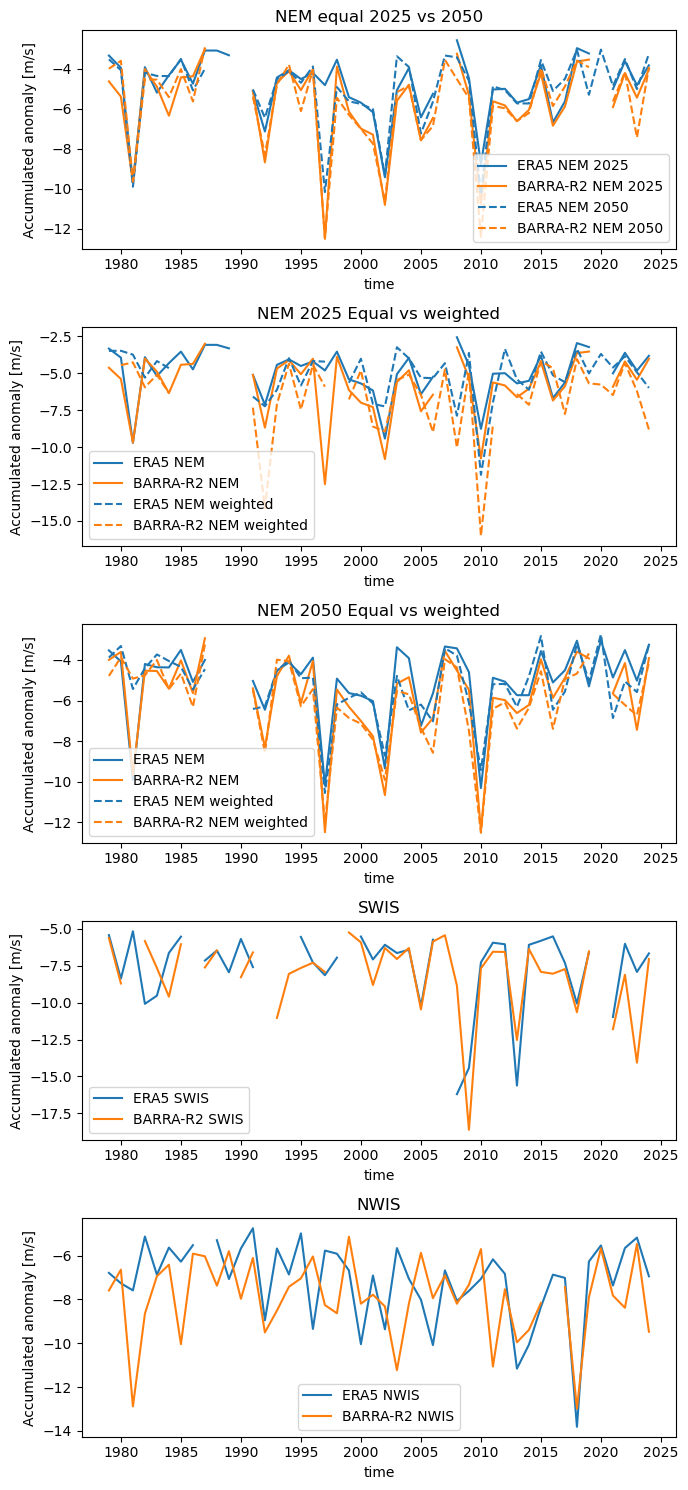

In [43]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_SWIS"]["drought_severity_p10"],
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
max_intensity(
    ws_dict["BARRA-R2_SWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

max_intensity(
    ws_dict["ERA5_NWIS"]["drought_severity_p10"],
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
max_intensity(
    ws_dict["BARRA-R2_NWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Accumulated anomaly [m/s]")
    
plt.tight_layout()